In [1]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords if not already
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Bibhuprasad
[nltk_data]     Das\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

## Data Exploration and Preprocessing

In [2]:
df = pd.read_csv('blogs.csv')
df.head()

,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


In [5]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (2000, 2)
Columns: ['Data', 'Labels']


In [4]:
# missing values
df.isnull().sum()

Data      0
Labels    0
dtype: int64

In [7]:
print("\nCategory distribution :")
print(df['Labels'].value_counts().sort_index())


Category distribution :
Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64


- The dataset contains 20 categories with 100 posts in each category, making it a perfectly balanced dataset.
- This ensures fair training and evaluation of the classification model.

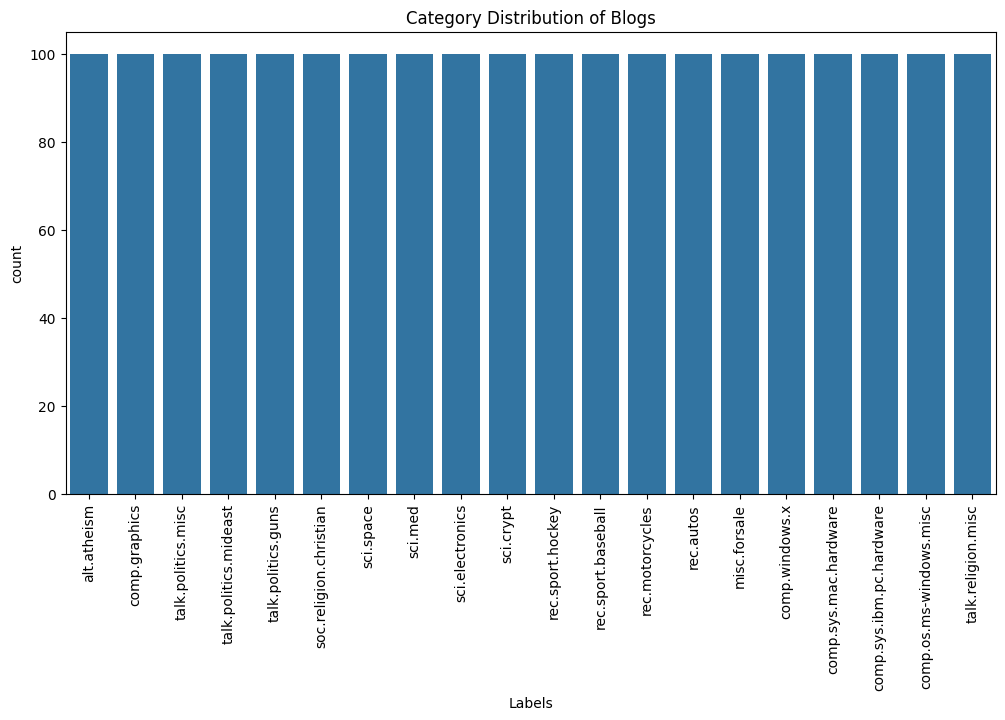

In [8]:
# Plot category distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Labels', order=df['Labels'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Category Distribution of Blogs")
plt.show()

The bar plot confirms that each category contains exactly 100 posts, showing a perfectly balanced dataset.

In [9]:
# Define stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                                # convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)               # remove punctuation/numbers
    tokens = text.split()                              # tokenization
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    return " ".join(tokens)

In [10]:
# Apply cleaning
df['clean_text'] = df['Data'].apply(clean_text)

In [11]:
# Add word count column for exploration
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

In [13]:
df[['clean_text', 'word_count']].head()

,clean_text,word_count
0,path cantaloupesrvcscmuedumagnesiumclubcccmued...,432
1,newsgroups altatheism path cantaloupesrvcscmue...,91
2,path cantaloupesrvcscmuedudasnewsharvardedunoc...,246
3,path cantaloupesrvcscmuedumagnesiumclubcccmued...,1274
4,xref cantaloupesrvcscmuedu altatheism talkreli...,217


In [14]:
df['word_count'].describe().T

count    2000.000000
mean      173.212000
std       291.087566
min        24.000000
25%        77.000000
50%       112.000000
75%       176.000000
max      5170.000000
Name: word_count, dtype: float64

In [15]:
# Convert text data into numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['Labels']

print("Shape of TF-IDF matrix:", X.shape)

Shape of TF-IDF matrix: (2000, 5000)


In [16]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 1600
Test size: 400


## Naive Bayes Model for Text Classification

In [17]:
# Initialize Naive Bayes classifier
nb_model = MultinomialNB()

# Train the model on training data
nb_model.fit(X_train, y_train)

# Make predictions on test set
y_pred = nb_model.predict(X_test)


In [21]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Estimated Accuracy:", round(accuracy, 4))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Estimated Accuracy: 0.85

Classification Report:

                          precision    recall  f1-score   support

             alt.atheism       0.84      0.80      0.82        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.84      0.80      0.82        20
comp.sys.ibm.pc.hardware       0.58      0.75      0.65        20
   comp.sys.mac.hardware       0.83      0.75      0.79        20
          comp.windows.x       0.84      0.80      0.82        20
            misc.forsale       0.86      0.90      0.88        20
               rec.autos       0.86      0.95      0.90        20
         rec.motorcycles       0.94      0.85      0.89        20
      rec.sport.baseball       1.00      0.95      0.97        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.87      1.00      0.93        20
         sci.electronics       0.84      0.80      0.82        20
                 sci.med 

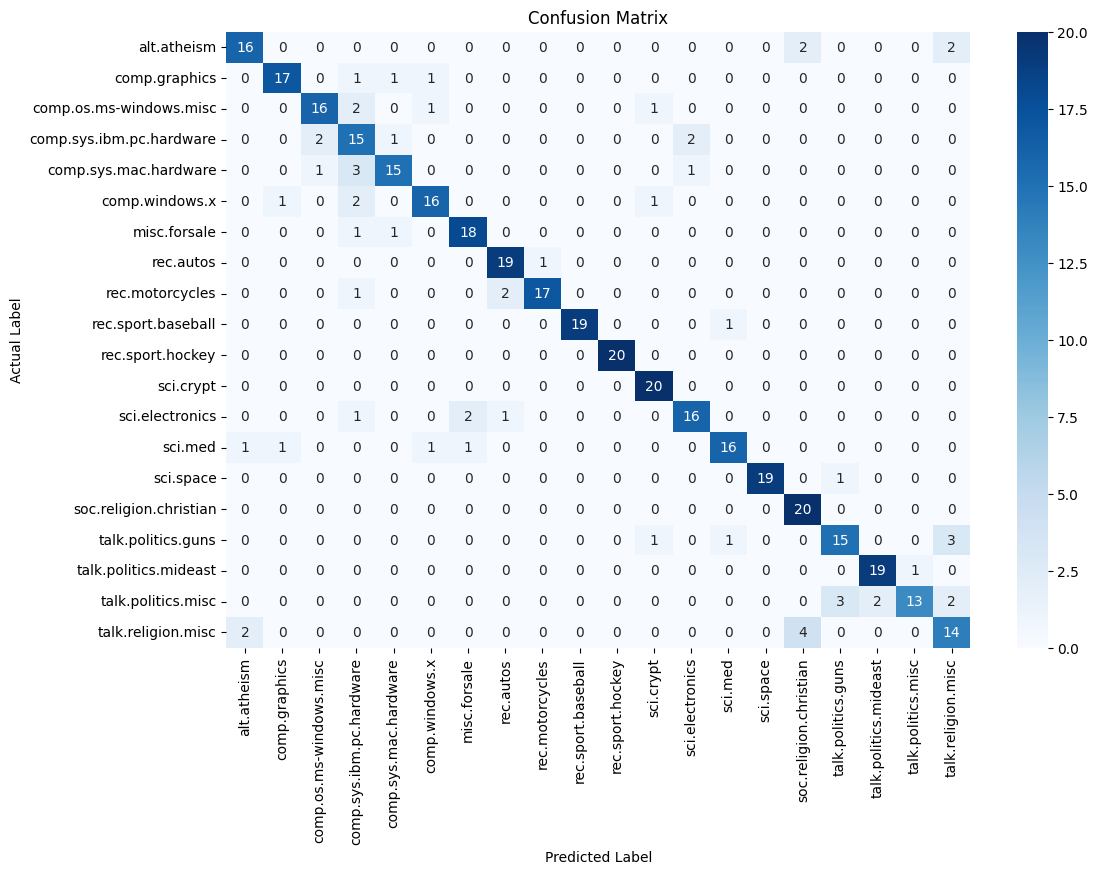

In [22]:
# Confusion matrix for visual inspection
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)

plt.figure(figsize=(12,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=nb_model.classes_,yticklabels=nb_model.classes_)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

- The Naive Bayes classifier achieved an overall accuracy of 85%.
-  Categories such as rec.sport.hockey, rec.sport.baseball, and sci.space achieved near-perfect precision and recall due to distinct vocabulary.
-  Some confusion was observed in similar technical and religious categories such as comp.sys.ibm.pc.hardware and talk.religion.misc, where overlapping terminology reduced performance slightly.
-  Overall, the model performs strongly across most categories.

## Sentiment Analysis

In [25]:
# Import sentiment analysis library
from textblob import TextBlob

# Define a function to classify sentiment
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity  # Polarity ranges from -1 to 1
    if score > 0.05:        # Positive threshold
        return 'positive'
    elif score < -0.05:     # Negative threshold
        return 'negative'
    else:
        return 'neutral'    # Polarity near zero is neutral

# Apply sentiment analysis on the original 'Data' column
df['sentiment'] = df['Data'].apply(get_sentiment)

# Preview results
sent_counts = pd.crosstab(df['Labels'], df['sentiment']).reindex(index=sorted(df['Labels'].unique()))
print("Sentiment counts by category (first 10 rows):")
display(sent_counts.head(10))

Sentiment counts by category (first 10 rows):


sentiment,negative,neutral,positive
Labels,,,
alt.atheism,12,28,60
comp.graphics,15,25,60
comp.os.ms-windows.misc,17,19,64
comp.sys.ibm.pc.hardware,12,27,61
comp.sys.mac.hardware,12,24,64
comp.windows.x,17,27,56
misc.forsale,13,21,66
rec.autos,11,20,69
rec.motorcycles,14,24,62


- Sentiment analysis was performed using TextBlob polarity scores. Across most categories, the majority of posts were classified as positive, followed by neutral and then negative.
-  This suggests that blog discussions tend to have a generally positive or informative tone.
-  Political and technical categories show a mix of sentiments, but strong negative polarity is relatively limited.

In [26]:
print(df[['Data', 'Labels', 'sentiment']].head(3))

                                                Data       Labels sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism  positive
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism  negative
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism  positive



Overall sentiment distribution:
sentiment
positive    1192
neutral      542
negative     266
Name: count, dtype: int64

Percentage distribution:
sentiment
positive    59.6
neutral     27.1
negative    13.3
Name: proportion, dtype: float64


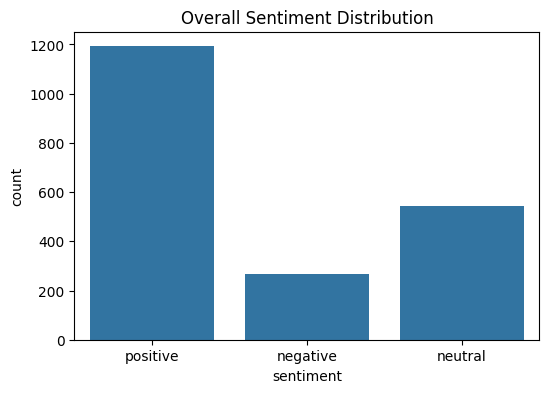

In [27]:
# Overall sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
sentiment_percent = df['sentiment'].value_counts(normalize=True) * 100

print("\nOverall sentiment distribution:")
print(sentiment_counts)

print("\nPercentage distribution:")
print(sentiment_percent.round(2))

# Plot sentiment distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', order=['positive', 'negative', 'neutral'])
plt.title("Overall Sentiment Distribution")
plt.show()




- The Naive Bayes model achieved an accuracy of 85% in classifying blog posts across 20 categories, showing strong performance overall.
- Sentiment analysis revealed that most posts are positive (59.6%), followed by neutral (27.1%) and negative (13.3%), indicating that discussions are generally constructive in nature.


Sentiment counts by category (first 10 rows):
sentiment                 negative  neutral  positive  total  positive_pct  \
Labels                                                                       
alt.atheism                     12       28        60    100          60.0   
comp.graphics                   15       25        60    100          60.0   
comp.os.ms-windows.misc         17       19        64    100          64.0   
comp.sys.ibm.pc.hardware        12       27        61    100          61.0   
comp.sys.mac.hardware           12       24        64    100          64.0   
comp.windows.x                  17       27        56    100          56.0   
misc.forsale                    13       21        66    100          66.0   
rec.autos                       11       20        69    100          69.0   
rec.motorcycles                 14       24        62    100          62.0   
rec.sport.baseball              17       27        56    100          56.0   

sentiment       

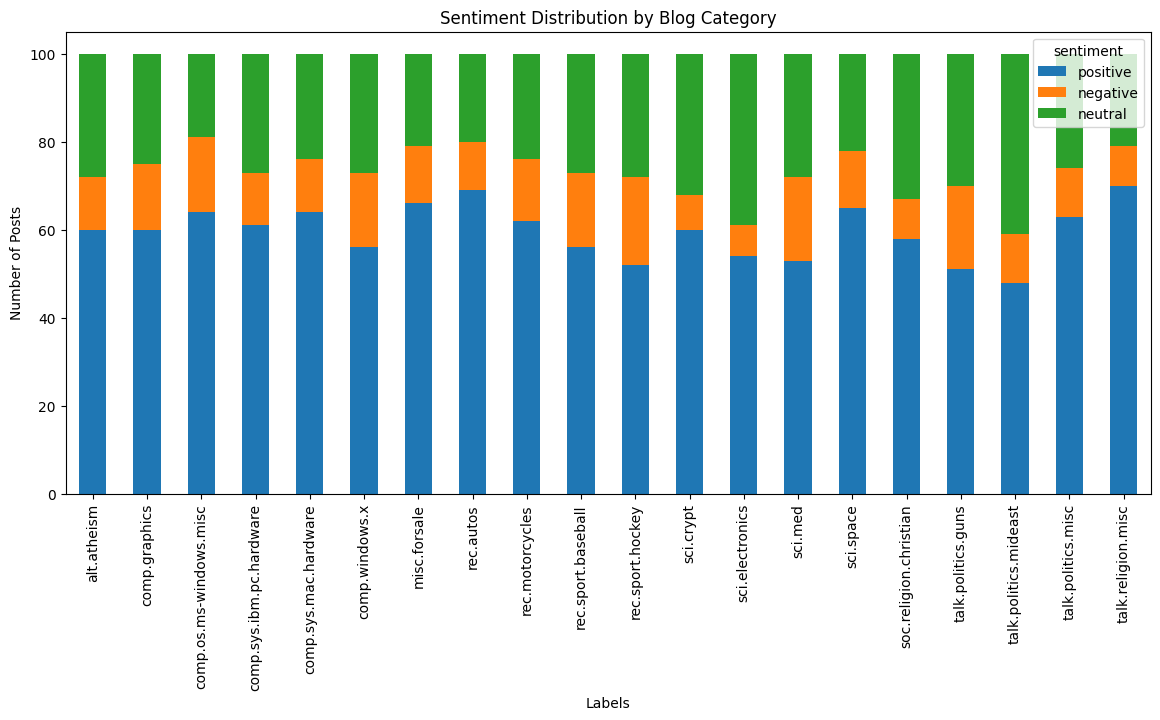

In [28]:
# Sentiment counts by category
sentiment_by_category = pd.crosstab(df['Labels'], df['sentiment'])
sentiment_by_category['total'] = sentiment_by_category.sum(axis=1)

# Calculate percentages for all sentiment types
for col in ['positive', 'negative', 'neutral']:
    if col in sentiment_by_category.columns:
        sentiment_by_category[f'{col}_pct'] = round(sentiment_by_category[col]/sentiment_by_category['total']*100, 2)
    else:
        sentiment_by_category[f'{col}_pct'] = 0.0

print("\nSentiment counts by category (first 10 rows):")
print(sentiment_by_category.head(10))

# Optional visualization
plot_cols = [col for col in ['positive', 'negative', 'neutral'] if col in sentiment_by_category.columns]
sentiment_by_category[plot_cols].plot(
    kind='bar', stacked=True, figsize=(14,6))
plt.title("Sentiment Distribution by Blog Category")
plt.ylabel("Number of Posts")
plt.show()


- The sentiment distribution across categories shows that positive sentiment dominates in most topics.
- Sports and technical categories tend to have higher positive proportions, while political and religious discussions show slightly higher negative percentages.
- However, positive sentiment remains the majority across all categories.

## Evaluation

In [29]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy of the Naive Bayes model
accuracy = accuracy_score(y_test, y_pred)
print(f"Estimated Accuracy of Naive Bayes Classifier: {accuracy:.4f}\n")

# Detailed classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)


Estimated Accuracy of Naive Bayes Classifier: 0.8500

Classification Report:
                           precision    recall  f1-score   support

             alt.atheism       0.84      0.80      0.82        20
           comp.graphics       0.89      0.85      0.87        20
 comp.os.ms-windows.misc       0.84      0.80      0.82        20
comp.sys.ibm.pc.hardware       0.58      0.75      0.65        20
   comp.sys.mac.hardware       0.83      0.75      0.79        20
          comp.windows.x       0.84      0.80      0.82        20
            misc.forsale       0.86      0.90      0.88        20
               rec.autos       0.86      0.95      0.90        20
         rec.motorcycles       0.94      0.85      0.89        20
      rec.sport.baseball       1.00      0.95      0.97        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.87      1.00      0.93        20
         sci.electronics       0.84      0.80      0.82        

- The Multinomial Naive Bayes classifier achieved an overall accuracy of 85% across 20 categories.
- The model performs strongly on well-defined topics such as sports and science, while minor confusion occurs among closely related technical and political categories.
-  Overall, the classifier demonstrates robust and balanced multi-class performance.

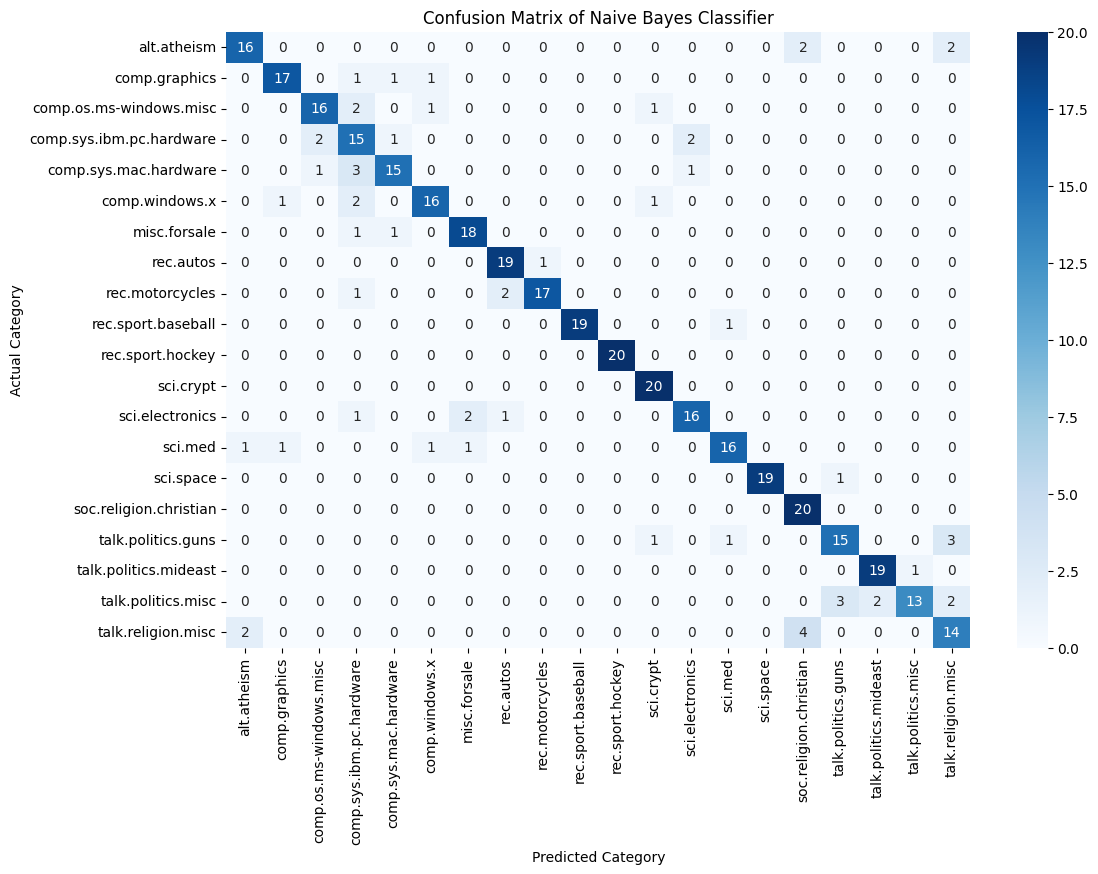

In [30]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title("Confusion Matrix of Naive Bayes Classifier")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()


The confusion matrix shows strong diagonal dominance, indicating high classification accuracy, with minor confusion among closely related technical and political categories.

#### Evaluation and Discussion

- The Naive Bayes model gave good results with an overall accuracy of 85%. It performed very well in categories like sports and science where the vocabulary is clear and specific. Some errors occurred in topics that are closely related, such as political or technical discussions, because they share similar words.

- The sentiment analysis showed that most posts have a positive tone. Neutral posts come next, and fewer posts are negative. Political and religious topics showed slightly more negative sentiment compared to other categories. Overall, this project helps us understand both what the posts are about and the tone in which they are written.

#### Performance of the Naive Bayes Model:

The Naive Bayes model achieved an accuracy of about 85% on the test data, which shows that it works well for classifying blog posts into 20 different categories. It performed especially well in categories like sports and science, where the language is more specific and easier to identify. However, it struggled slightly with some technical and religious categories. This is likely because those topics use similar words or contain mixed discussions, making them harder to separate clearly.

#### Challenges Faced:

1. The dataset contains a large variety of words across categories, which can make it harder for the model to correctly estimate probabilities for less common words.

2. Some posts include extra information such as links, email addresses, or headers. Even after cleaning, this kind of text can still affect the features used for classification.

3. Although the dataset is balanced, certain categories are naturally more similar to each other, which increases the chance of confusion between them.

#### Reflection on Sentiment Analysis

- The sentiment analysis shows that most blog posts have a positive tone. A smaller number of posts are negative, and some are neutral depending on the category. This means that even when discussing technical or controversial topics, bloggers generally express themselves in a constructive or positive way.

- Categories like rec.autos and misc.forsale have higher positive sentiment, possibly because they focus on sharing information, reviews, or selling products. On the other hand, categories such as comp.windows.x and rec.motorcycles show slightly more negative sentiment, which may come from complaints, technical problems, or discussions with differing opinions.

- Neutral sentiment appears in many categories, suggesting that several posts are mainly informative and do not express strong emotions.

#### Implication

By combining sentiment analysis with the Naive Bayes classification model (85% accuracy), we gain a better understanding of both what the posts are about and how people feel about those topics. This approach can be useful for applications like content filtering, recommendation systems, and analyzing public opinion trends.


### Conclusion

- In this project, we applied the Naive Bayes algorithm to classify blog posts into different categories and used TextBlob to analyze their sentiment. The model achieved good accuracy in predicting the correct category, showing that Naive Bayes works well for text classification when combined with TF-IDF features.

- The sentiment analysis showed that most blog posts have a positive tone, which adds more insight beyond just identifying the topic. Overall, this project demonstrates how combining text classification and sentiment analysis can help us understand both the subject and emotional tone of written content.